# Problem 1: Packing

Given 4 circles of radii 10cm, 6cm, 5cm and 3cm, find a rectangle of smallest
area in which we can pack them without overlapping.

Let the origin (0, 0) and (l, b) be the opposite corners of the rectangle. Let
$(x_1 , y_1 ), ..., (x_4 , y_4 )$ be the coordinates of the centres of the 4 circles.

1. Run the code as is and see the (incorrect) solution at the bottom.
2. Write a mathmatical model for this problem on a piece of paper.
2. Add missing constraints (in 3 places). Uncomment the code to select ipopt as the solver. Run to see a solution.
3. Change the initialization values near the top of the model to see if the solution changes when initial values are changed. Why do you think this happens?
4. Try with the Minotaur's mglob solver for a globally optimal solution (comment out the line for ipopt and enable mglob). Note the optimal value, time, size of branch-and-bound tree. One needs branch-and-bound for global optimization even when there are no integer variables.


Installing IPOPT
--2026-06-04 02:21:58--  https://drive.google.com/uc?export=download&id=1VvlnWUkF6nAh0gWBcvfX3KsRhoDaTW7X
Resolving drive.google.com (drive.google.com)... 74.125.141.102, 74.125.141.138, 74.125.141.101, ...
Connecting to drive.google.com (drive.google.com)|74.125.141.102|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1VvlnWUkF6nAh0gWBcvfX3KsRhoDaTW7X&export=download [following]
--2026-06-04 02:21:58--  https://drive.usercontent.google.com/download?id=1VvlnWUkF6nAh0gWBcvfX3KsRhoDaTW7X&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 74.125.134.132, 2607:f8b0:400c:c00::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|74.125.134.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6842253 (6.5M) [application/octet-stream]
Saving to: ‘ipopt’

ipopt               100%[===================>]   6.52M  

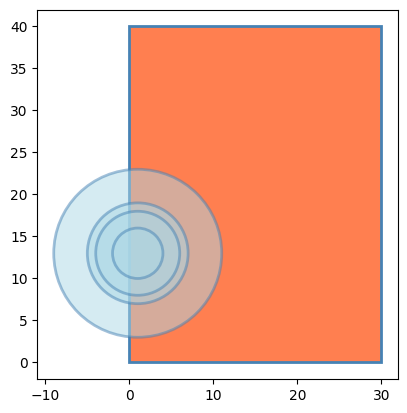

In [1]:
## Download IPOPT and Minotaur, open-source solvers for finding local and global solutions
!if [ ! -f ipopt ] ; then echo "Installing IPOPT" ; rm -fv ipopt mglob;  wget "https://drive.google.com/uc?export=download&id=1VvlnWUkF6nAh0gWBcvfX3KsRhoDaTW7X" -O ipopt;  wget "https://drive.google.com/uc?export=download&id=1l2f64HbLPxtTtJbz6AceBT4L4duvCzIo" -O mglob; chmod 755 ipopt mglob; fi



import pyomo.environ as pyo
import matplotlib.pyplot as plt
import matplotlib.patches as patches

C = range(4)
R = [10, 6, 5, 3]



model = pyo.ConcreteModel()

model.x = pyo.Var(C, within=pyo.Reals, initialize=1)
model.y = pyo.Var(C, within=pyo.Reals, initialize=13)
model.l = pyo.Var(within=pyo.NonNegativeReals, initialize=30)
model.b = pyo.Var(within=pyo.NonNegativeReals, initialize=40)


model.obj = pyo.Objective(sense=pyo.minimize, expr= (model.l * model.b))


## Circles should be inside the rectangle
def in_l_low_rule(model, i):
  return (model.x[i] >= R[i])

def in_l_up_rule(model, i):
  # TO DO: fill up this constraint
  return (pyo.Constraint.Skip)

def in_b_low_rule(model, i):
  return (model.y[i] >= R[i])

def in_b_up_rule(model, i):
  # TO DO: fill up this constraint
  return (pyo.Constraint.Skip)


model.in_l_low = pyo.Constraint(C, rule=in_l_low_rule)
model.in_l_up = pyo.Constraint(C, rule=in_l_up_rule)
model.in_b_low = pyo.Constraint(C, rule=in_b_low_rule)
model.in_b_up = pyo.Constraint(C, rule=in_b_up_rule)

## Circles should not overlap
def no_overlap_rule(model, i, j):
  if (i==j):
    return (pyo.Constraint.Skip)
  else:
    # TO DO: fix this constraint
    return (pyo.Constraint.Skip)

model.no_overlap = pyo.Constraint(C, C, rule=no_overlap_rule)



## Call the solver
#solver = pyo.SolverFactory("ipopt", executable="/content/ipopt")
#solver = pyo.SolverFactory("mglob", executable="/content/mglob")

###### NO NEED TO EDIT FURTHER #######

## Solve
try:
  result = solver.solve(model, tee=False)

  print("Solver termination status:",result.solver.status)
  print("Solver time:", f"{result.solver.time:.2f}"+" seconds")
  print("Solver termination condition:", result.solver.termination_condition)
  print("Best solution value:", f"{model.obj():.2f}")

except Exception as e:
        print("Error solving the model. Could not load results.")
        print(e)

print()
print ("Solution: ")
for v in model.component_data_objects(pyo.Var, active=True):
  print(v, f"{pyo.value(v):.4f}")

print()
print()

## Plot
fig, ax = plt.subplots()
rect = patches.Rectangle((0, 0), pyo.value(model.l), pyo.value(model.b),
                         linewidth=2, edgecolor='steelblue',
                         facecolor='coral')
ax.add_patch(rect)

for i in C:
  circle = plt.Circle((pyo.value(model.x[i]), pyo.value(model.y[i])), R[i], linewidth=2, edgecolor='steelblue', facecolor='lightblue', alpha=0.5)
  ax.add_patch(circle)
ax.plot()
ax.set_aspect('equal')
plt.show()





